In [1]:
# CELL 1: Setup
import sys
sys.path.append('..')

import os
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp

from configs.config import Config
from data.splits import get_loaders, get_datasets
from models.bu_net import BUNet
from models.prototypical_segmentation import PrototypicalSegmentation
from models.maml_segmentation import MAMLSegmentation
from configs.results_utils import load_results, print_comparison_table
from configs.model_utils import load_model_weights

Config.create_dirs()
print(f"✓ Device: {Config.DEVICE}")

Verifying BraTS2020 dataset via KaggleHub...
✓ Device: mps


In [2]:
# CELL 2: Load All Results
baseline_results = load_results(Config.RESULTS_DIR, 'baseline_kshot_results.json')
proto_results = load_results(Config.RESULTS_DIR, 'prototypical_kshot_results.json')
maml_results = load_results(Config.RESULTS_DIR, 'maml_kshot_results.json')

for name, r in [('Baseline', baseline_results),
                ('Prototypical', proto_results),
                ('MAML', maml_results)]:
    if r:
        print(f"✓ {name} results loaded")
    else:
        print(f"✗ {name} results missing")

✓ Baseline results loaded
✓ Prototypical results loaded
✓ MAML results loaded


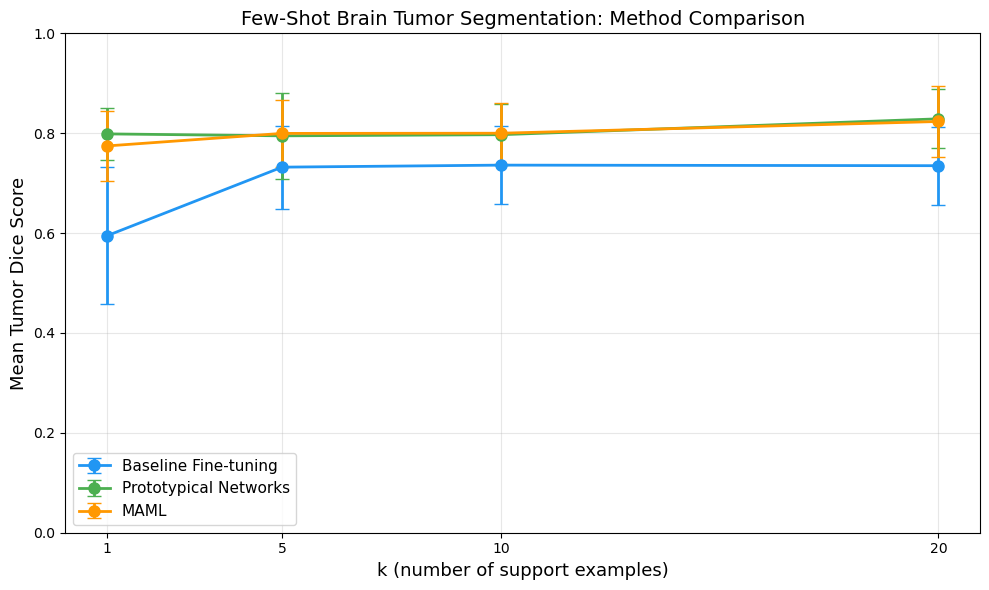

In [3]:
# CELL 3: Method Comparison Chart
k_values = Config.K_SHOT_VALUES
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'Baseline Fine-tuning': '#2196F3',
          'Prototypical Networks': '#4CAF50',
          'MAML': '#FF9800'}

for name, results, color in [
    ('Baseline Fine-tuning', baseline_results, colors['Baseline Fine-tuning']),
    ('Prototypical Networks', proto_results, colors['Prototypical Networks']),
    ('MAML', maml_results, colors['MAML']),
]:
    if results is None:
        continue
    means = [results[str(k)]['mean'] for k in k_values]
    stds = [results[str(k)]['std'] for k in k_values]
    ax.errorbar(k_values, means, yerr=stds, marker='o', capsize=5,
                linewidth=2, markersize=8, color=color, label=name)

ax.set_xlabel('k (number of support examples)', fontsize=13)
ax.set_ylabel('Mean Tumor Dice Score', fontsize=13)
ax.set_title('Few-Shot Brain Tumor Segmentation: Method Comparison', fontsize=14)
ax.set_xticks(k_values)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(Config.RESULTS_DIR, 'method_comparison.png'), dpi=150)
plt.show()

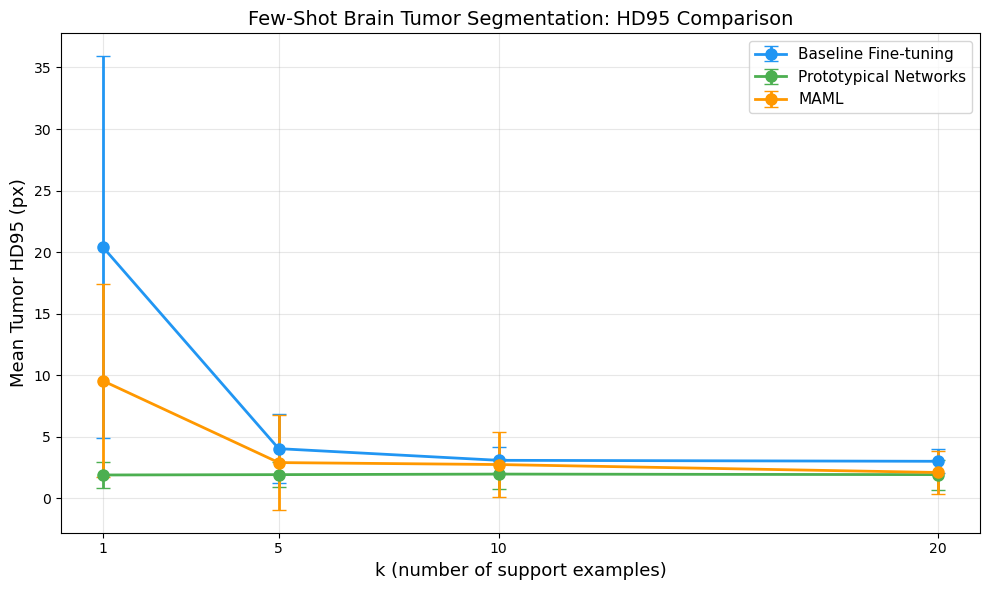

In [15]:
# CELL 4: HD95 Method Comparison Chart
k_values = Config.K_SHOT_VALUES
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'Baseline Fine-tuning': '#2196F3',
          'Prototypical Networks': '#4CAF50',
          'MAML': '#FF9800'}

for name, results, color in [
    ('Baseline Fine-tuning', baseline_results, colors['Baseline Fine-tuning']),
    ('Prototypical Networks', proto_results, colors['Prototypical Networks']),
    ('MAML', maml_results, colors['MAML']),
]:
    if results is None:
        continue
    # Check if HD95 data exists
    if 'hd95_mean' not in results[str(k_values[0])]:
        print(f"⚠ {name}: no HD95 data — re-run evaluation with compute_hd95=True")
        continue
    means = [results[str(k)]['hd95_mean'] for k in k_values]
    stds = [results[str(k)]['hd95_std'] for k in k_values]
    ax.errorbar(k_values, means, yerr=stds, marker='o', capsize=5,
                linewidth=2, markersize=8, color=color, label=name)

ax.set_xlabel('k (number of support examples)', fontsize=13)
ax.set_ylabel('Mean Tumor HD95 (px)', fontsize=13)
ax.set_title('Few-Shot Brain Tumor Segmentation: HD95 Comparison', fontsize=14)
ax.set_xticks(k_values)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(Config.RESULTS_DIR, 'method_comparison_hd95.png'), dpi=150)
plt.show()

In [4]:
# CELL 5: Load Models for Visualization
train_loader, val_loader, test_loader = get_loaders(Config)
train_dataset, val_dataset, test_dataset = get_datasets(Config)

# --- Baseline ---
baseline_model = BUNet(
    encoder_name=Config.ENCODER_NAME,
    in_channels=Config.IN_CHANNELS,
    num_classes=Config.NUM_CLASSES,
).to(Config.DEVICE)
load_model_weights(baseline_model, Config.CHECKPOINT_DIR, 'best_model.pth', Config.DEVICE)
baseline_model.eval()

# --- Prototypical ---
proto_model = PrototypicalSegmentation(
    encoder_name=Config.ENCODER_NAME,
    in_channels=Config.IN_CHANNELS,
    num_classes=Config.NUM_CLASSES,
).to(Config.DEVICE)
load_model_weights(proto_model, Config.CHECKPOINT_DIR, 'prototypical_ep1000.pth', Config.DEVICE)
proto_model.eval()

# --- MAML ---
maml_model = MAMLSegmentation(
    encoder_name=Config.ENCODER_NAME,
    in_channels=Config.IN_CHANNELS,
    num_classes=Config.NUM_CLASSES,
).to(Config.DEVICE)

checkpoint = torch.load(
    os.path.join(Config.CHECKPOINT_DIR, 'maml_task1000.pth'),
    weights_only=False, map_location=Config.DEVICE,
)

maml_model.model.load_state_dict(checkpoint['model_state_dict'], strict=False)
maml_model.eval()

loss_fn = smp.losses.DiceLoss(mode='multiclass')
sample = train_dataset[500]
img = sample['image'].unsqueeze(0).to(Config.DEVICE)
mask = sample['mask'].unsqueeze(0).to(Config.DEVICE)

with torch.no_grad():
    for name, m in [('Baseline', baseline_model), ('Proto', proto_model), ('MAML', maml_model)]:
        pred = m(img)
        loss = loss_fn(pred, mask)
        print(f"  {name}: output shape={pred.shape}, loss={loss.item():.4f}")

print("✓ All models loaded and verified")

✓ Splits -> Train: 258, Val: 74, Test: 37
✓ Valid patients: 258/258
✓ Valid patients: 74/74
✓ Valid patients: 37/37
✓ Train batches: 3225
✓ Val batches:   925
✓ Test batches:  463
✓ Splits -> Train: 258, Val: 74, Test: 37
✓ Valid patients: 258/258
✓ Valid patients: 74/74
✓ Valid patients: 37/37
✓ Loaded checkpoint: best_model.pth
✓ Loaded checkpoint: prototypical_ep1000.pth
  Baseline: output shape=torch.Size([1, 4, 128, 128]), loss=0.0000
  Proto: output shape=torch.Size([1, 4, 128, 128]), loss=0.0000
  MAML: output shape=torch.Size([1, 4, 128, 128]), loss=0.0000
✓ All models loaded and verified


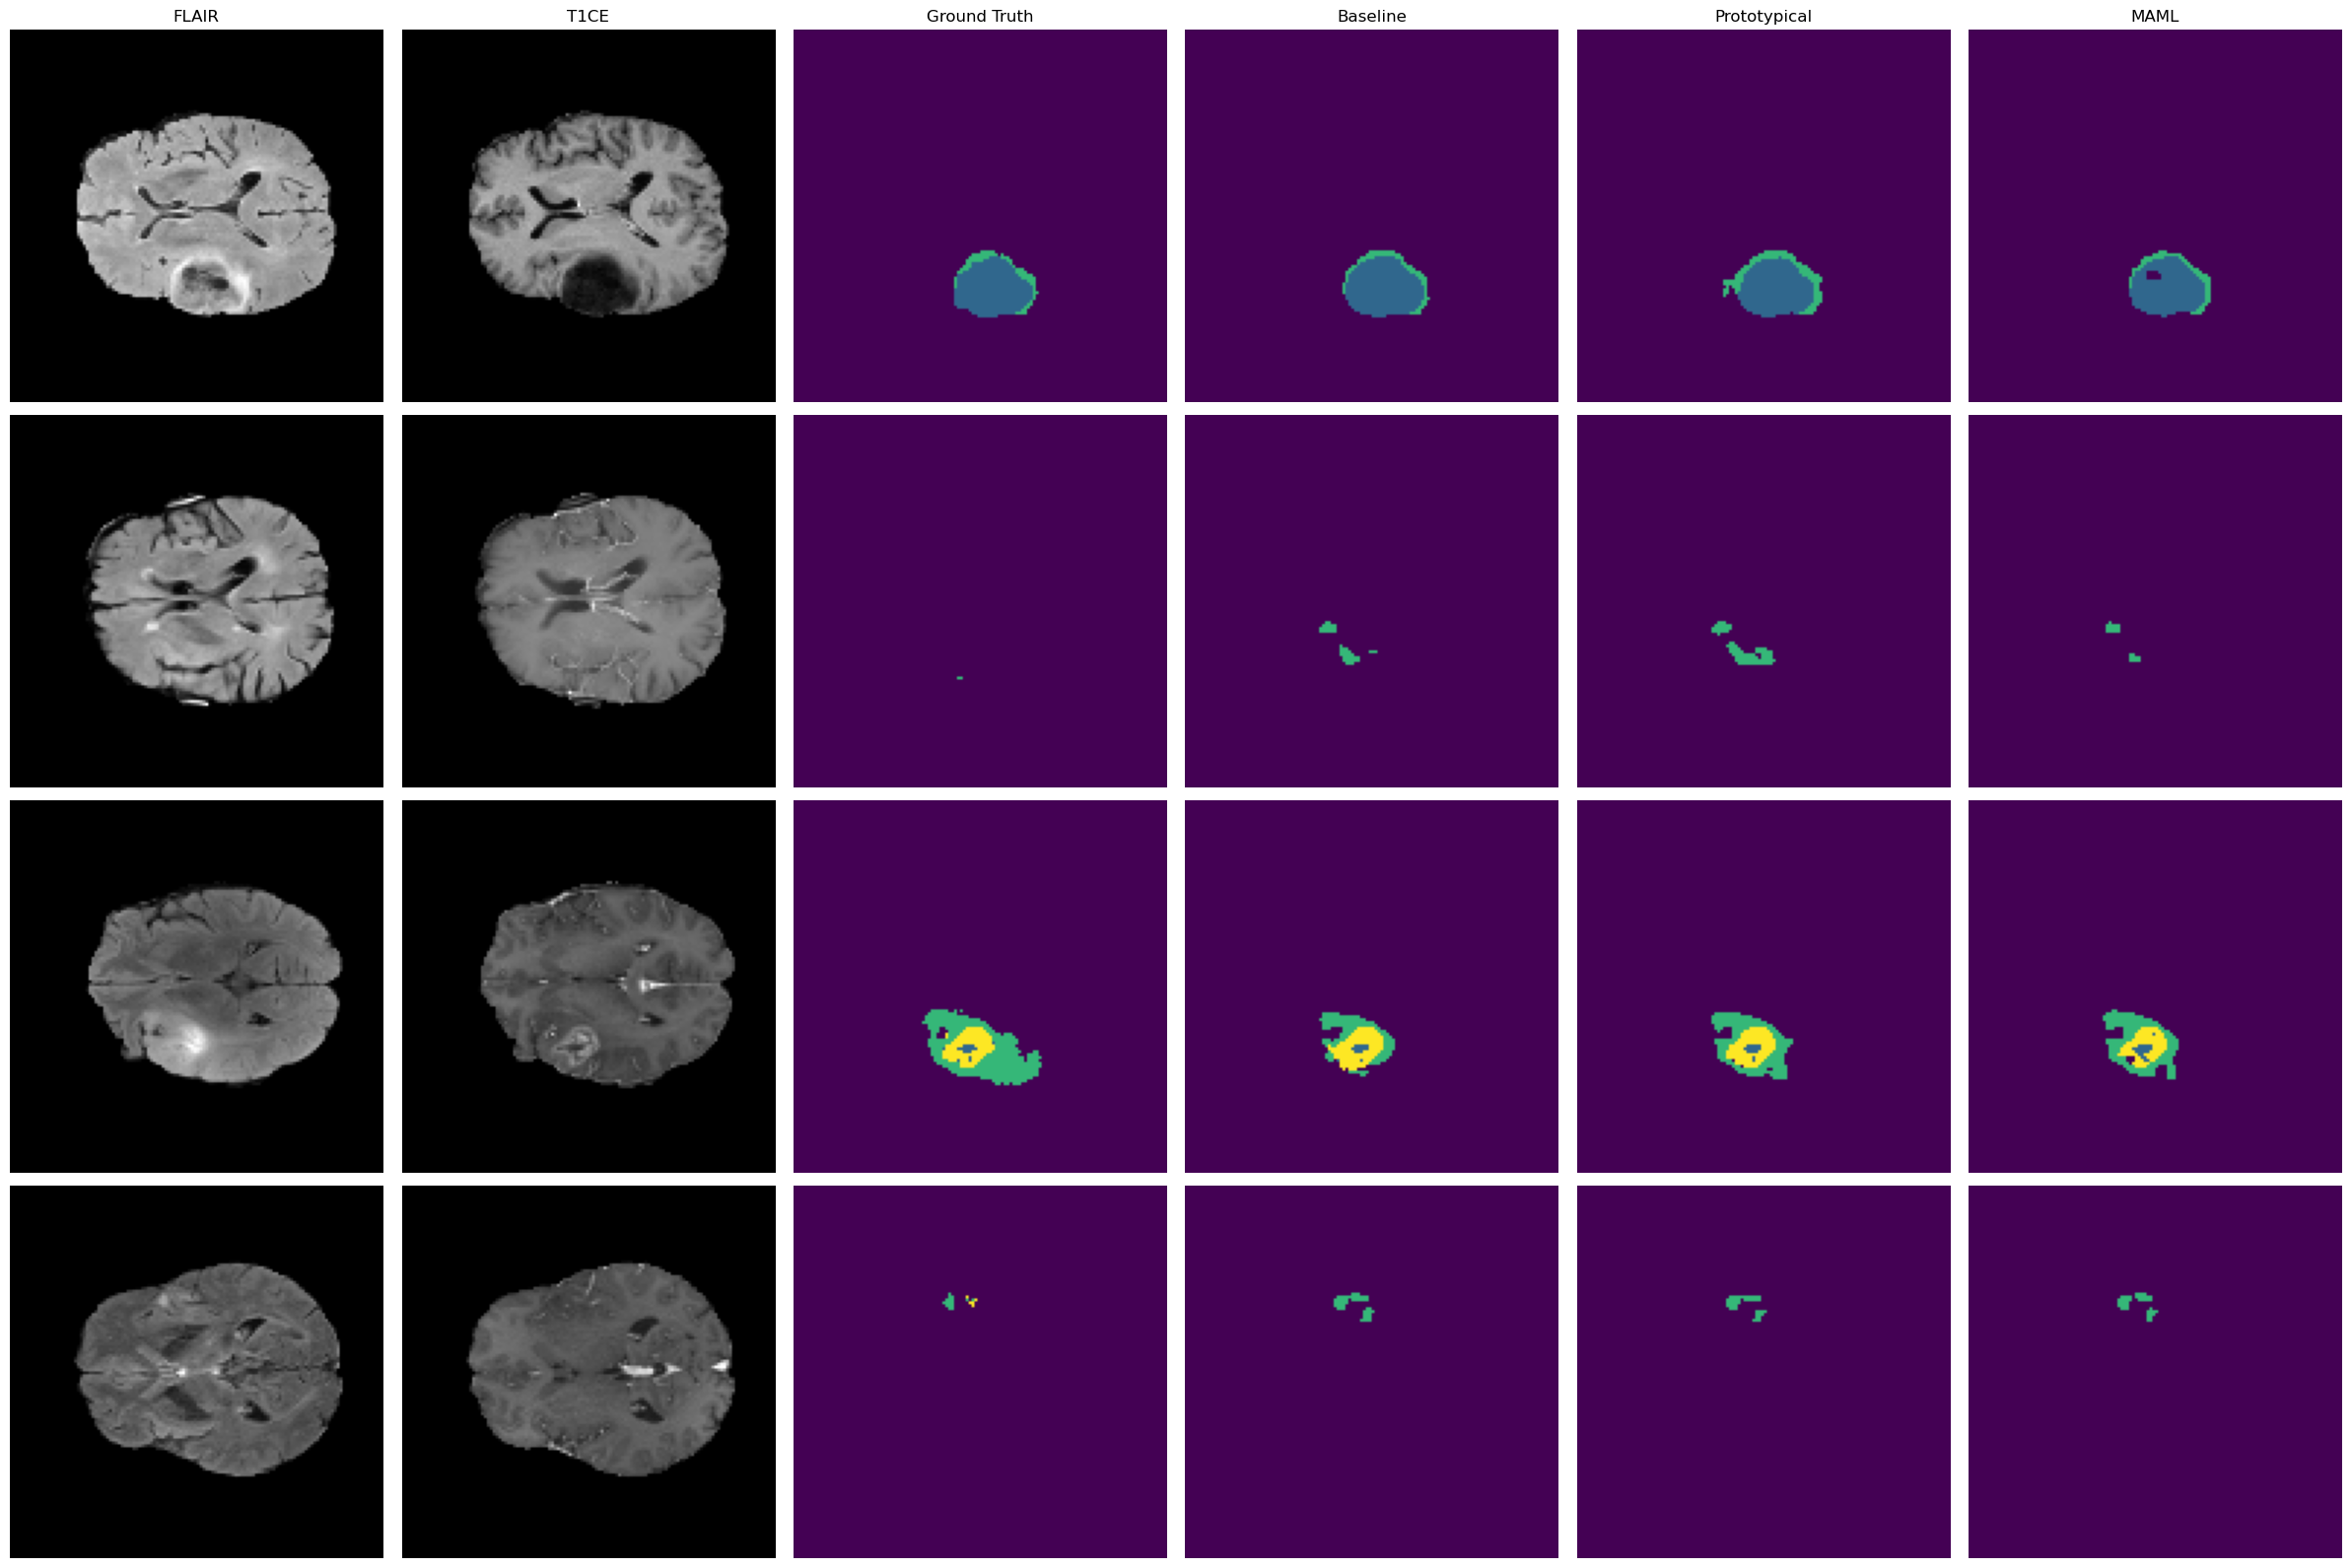

In [5]:
# CELL 6: Prediction Comparison
def show_predictions(models, model_names, dataset, sample_indices,
                     save_name='prediction_comparison.png'):
    """Side-by-side predictions from multiple models."""
    n_samples = len(sample_indices)
    n_cols = 3 + len(models)
    fig, axes = plt.subplots(n_samples, n_cols, figsize=(4 * n_cols, 4 * n_samples))

    if n_samples == 1:
        axes = axes[np.newaxis, :]

    for row, idx in enumerate(sample_indices):
        sample = dataset[idx]
        image = sample['image']
        mask = sample['mask']

        axes[row, 0].imshow(image[0], cmap='gray')
        axes[row, 0].set_title('FLAIR' if row == 0 else '')
        axes[row, 0].axis('off')

        axes[row, 1].imshow(image[1], cmap='gray')
        axes[row, 1].set_title('T1CE' if row == 0 else '')
        axes[row, 1].axis('off')

        axes[row, 2].imshow(mask, cmap='viridis', vmin=0, vmax=3)
        axes[row, 2].set_title('Ground Truth' if row == 0 else '')
        axes[row, 2].axis('off')

        for col, (model, name) in enumerate(zip(models, model_names)):
            with torch.no_grad():
                inp = image.unsqueeze(0).to(Config.DEVICE)
                pred = torch.argmax(model(inp), dim=1).squeeze().cpu()
            axes[row, 3 + col].imshow(pred, cmap='viridis', vmin=0, vmax=3)
            axes[row, 3 + col].set_title(name if row == 0 else '')
            axes[row, 3 + col].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(Config.RESULTS_DIR, save_name), dpi=150)
    plt.show()

# Pick tumor slices
tumor_indices = []
for i in range(0, len(val_dataset), 50):
    sample = val_dataset[i]
    if sample['mask'].max() > 0:
        tumor_indices.append(i)
    if len(tumor_indices) >= 4:
        break

show_predictions(
    models=[baseline_model, proto_model, maml_model],
    model_names=['Baseline', 'Prototypical', 'MAML'],
    dataset=val_dataset,
    sample_indices=tumor_indices,
)

Class presence analysis:
  Class 0: 50/50 slices (full res) → 50/50 (4×4)
  Class 1: 46/50 slices (full res) → 29/50 (4×4)
  Class 2: 50/50 slices (full res) → 0/50 (4×4)
  Class 3: 22/50 slices (full res) → 0/50 (4×4)


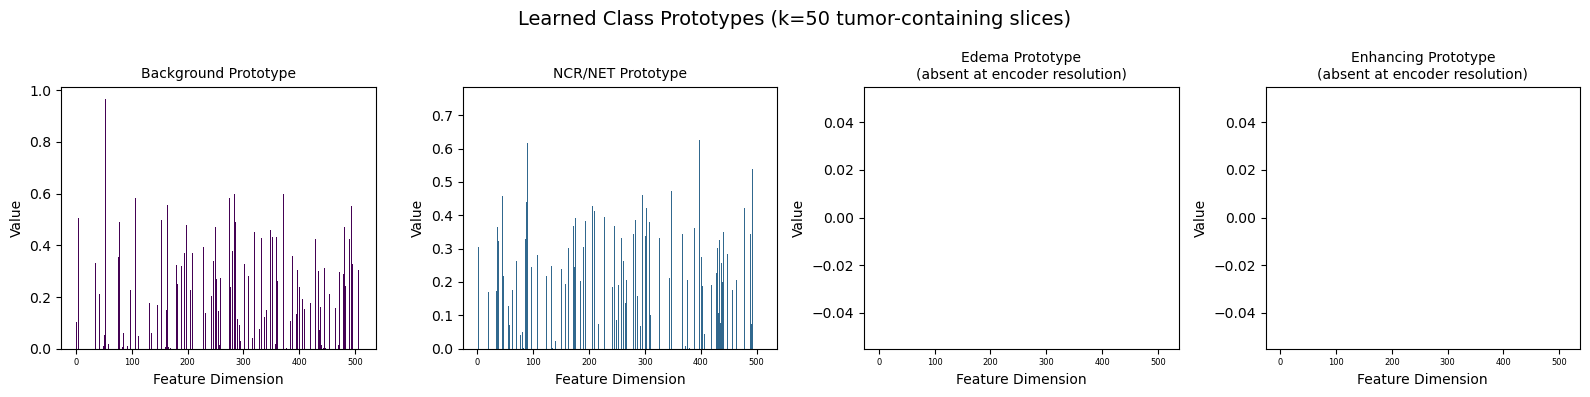

In [6]:
# CELL 7: Prototype Visualization
def visualize_prototypes(model, dataset, k=50, save_name='prototype_viz.png'):
    """Show class prototypes — empty bars indicate classes absent at encoder resolution."""
    tumor_indices = []
    for i in range(len(dataset)):
        if dataset[i]['mask'].max() > 0:
            tumor_indices.append(i)
        if len(tumor_indices) >= k:
            break

    support_imgs = torch.stack([dataset[i]['image'] for i in tumor_indices]).to(Config.DEVICE)
    support_masks = torch.stack([dataset[i]['mask'] for i in tumor_indices]).to(Config.DEVICE)

    # Check class presence at full resolution vs encoder resolution
    print("Class presence analysis:")
    for c in range(4):
        full_res = (support_masks == c).any(dim=(1,2)).sum().item()
        # Simulate downsampling to encoder feature map size (4x4)
        masks_down = torch.nn.functional.interpolate(
            support_masks.unsqueeze(1).float(), size=(4, 4), mode='nearest'
        ).squeeze(1)
        low_res = (masks_down == c).any(dim=(1,2)).sum().item()
        print(f"  Class {c}: {full_res}/{k} slices (full res) → {low_res}/{k} (4×4)")

    prototypes = model.compute_prototypes(support_imgs, support_masks)

    class_names = ['Background', 'NCR/NET', 'Edema', 'Enhancing']
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    for i, (proto, name) in enumerate(zip(prototypes, class_names)):
        proto_np = proto.cpu().numpy()
        is_empty = np.abs(proto_np).max() < 1e-5
        axes[i].bar(range(len(proto_np)), proto_np, color=plt.cm.viridis(i / 3))
        title = f'{name} Prototype'
        if is_empty:
            title += '\n(absent at encoder resolution)'
        axes[i].set_title(title, fontsize=10)
        axes[i].set_xlabel('Feature Dimension')
        axes[i].set_ylabel('Value')
        axes[i].tick_params(axis='x', labelsize=6)

    plt.suptitle(f'Learned Class Prototypes (k={k} tumor-containing slices)', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(Config.RESULTS_DIR, save_name), dpi=150)
    plt.show()

visualize_prototypes(proto_model, val_dataset, k=50)

Hardest slice: index 940, loss 0.7516


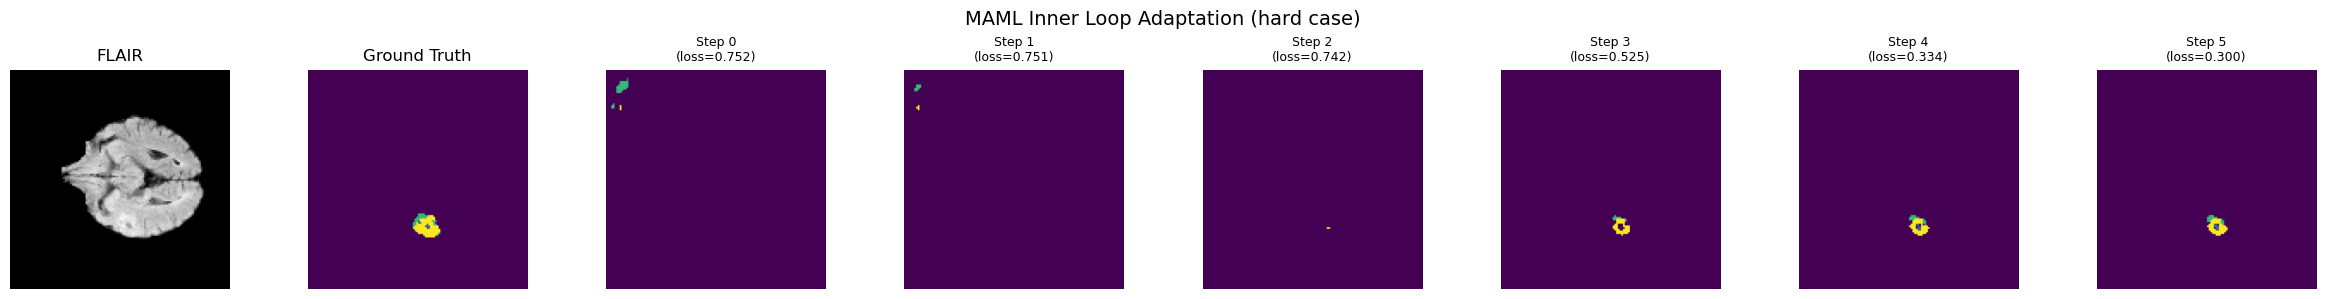

In [7]:
# CELL 8: MAML Adaptation Visualization
# Find a slice where the model initially struggles
import segmentation_models_pytorch as smp
import copy
loss_fn = smp.losses.DiceLoss(mode='multiclass')

hard_idx = None
worst_loss = 0

maml_model.eval()
for i in range(0, len(val_dataset), 10):
    sample = val_dataset[i]
    if sample['mask'].max() == 0:
        continue
    img = sample['image'].unsqueeze(0).to(Config.DEVICE)
    msk = sample['mask'].unsqueeze(0).to(Config.DEVICE)
    with torch.no_grad():
        pred = maml_model(img)
        loss = loss_fn(pred, msk).item()
    if loss > worst_loss:
        worst_loss = loss
        hard_idx = i

print(f"Hardest slice: index {hard_idx}, loss {worst_loss:.4f}")

def visualize_maml_adaptation(maml_model, dataset, sample_idx, num_inner_steps=5,
                               inner_lr=0.01, save_name='maml_adaptation.png'):
    """Show how MAML predictions improve across inner loop steps."""
    sample = dataset[sample_idx]
    image = sample['image'].unsqueeze(0).to(Config.DEVICE)
    mask = sample['mask']

    adapted = copy.deepcopy(maml_model.model).to(Config.DEVICE)
    inner_opt = torch.optim.SGD(adapted.parameters(), lr=inner_lr)
    loss_fn = smp.losses.DiceLoss(mode='multiclass')

    predictions = []
    losses = []
    step_labels = ['Step 0\n(before adapt)']

    # Before adaptation
    adapted.eval()
    with torch.no_grad():
        out = adapted(image)
        pred = torch.argmax(out, dim=1).squeeze().cpu()
        loss = loss_fn(out, mask.unsqueeze(0).to(Config.DEVICE)).item()
    predictions.append(pred)
    losses.append(loss)

    # After each inner loop step
    adapted.train()
    for step in range(num_inner_steps):
        inner_opt.zero_grad()
        out = adapted(image)
        loss = loss_fn(out, mask.unsqueeze(0).to(Config.DEVICE))
        loss.backward()
        inner_opt.step()

        adapted.eval()
        with torch.no_grad():
            out = adapted(image)
            pred = torch.argmax(out, dim=1).squeeze().cpu()
            l = loss_fn(out, mask.unsqueeze(0).to(Config.DEVICE)).item()
        predictions.append(pred)
        losses.append(l)
        step_labels.append(f'Step {step + 1}\n(loss={l:.3f})')
        adapted.train()

    step_labels[0] = f'Step 0\n(loss={losses[0]:.3f})'

    n_cols = 2 + len(predictions)
    fig, axes = plt.subplots(1, n_cols, figsize=(3 * n_cols, 3))

    axes[0].imshow(sample['image'][0], cmap='gray')
    axes[0].set_title('FLAIR')
    axes[0].axis('off')

    axes[1].imshow(mask, cmap='viridis', vmin=0, vmax=3)
    axes[1].set_title('Ground Truth')
    axes[1].axis('off')

    for i, (pred, label) in enumerate(zip(predictions, step_labels)):
        axes[2 + i].imshow(pred, cmap='viridis', vmin=0, vmax=3)
        axes[2 + i].set_title(label, fontsize=9)
        axes[2 + i].axis('off')

    plt.suptitle('MAML Inner Loop Adaptation (hard case)', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(Config.RESULTS_DIR, save_name), dpi=150)
    plt.show()

visualize_maml_adaptation(maml_model, val_dataset, sample_idx=hard_idx)

/var/folders/n0/yr9djtls6mg3nrk6zfj9t54m0000gn/T/ipykernel_68007/3326008283.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=class_names, patch_artist=True)
/var/folders/n0/yr9djtls6mg3nrk6zfj9t54m0000gn/T/ipykernel_68007/3326008283.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=class_names, patch_artist=True)
/var/folders/n0/yr9djtls6mg3nrk6zfj9t54m0000gn/T/ipykernel_68007/3326008283.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=class_names, patch_artist=True)


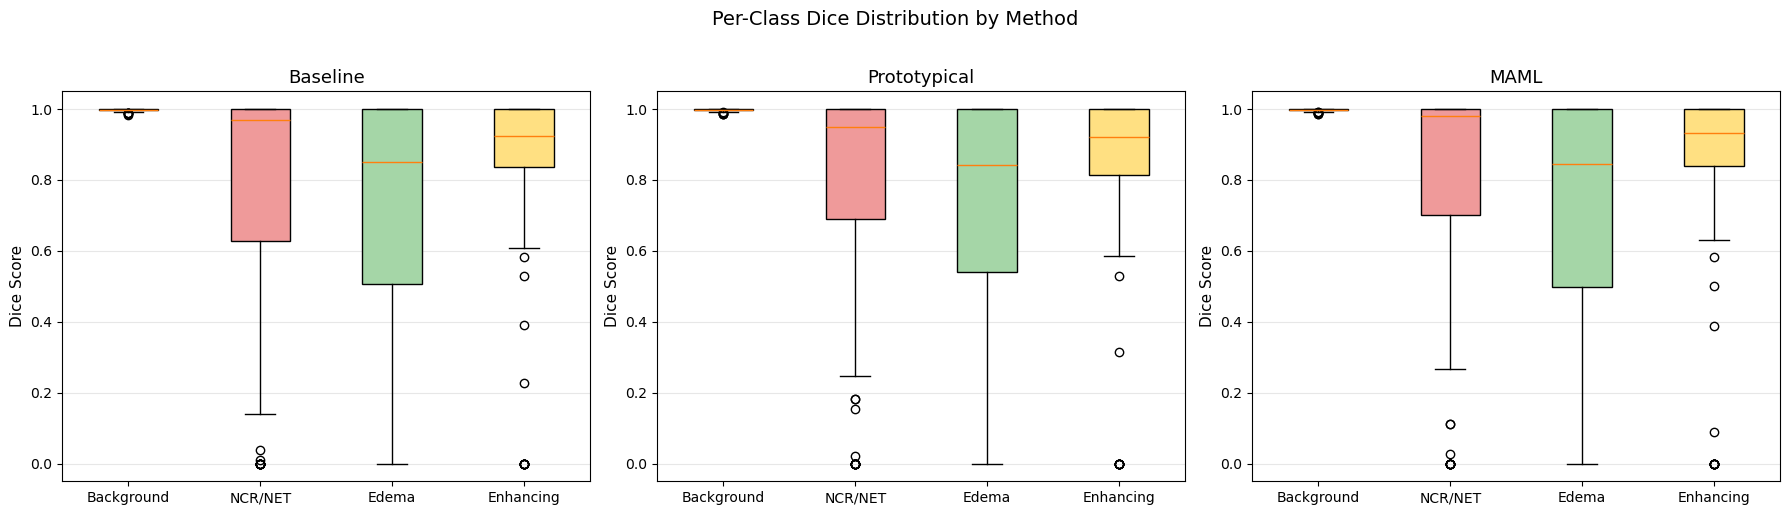

In [8]:
# CELL 9: Error Analysis — All Three Models
def error_analysis_all(models, model_names, dataset, num_samples=100,
                       save_name='error_analysis_all.png'):
    """Per-class Dice distribution for multiple models side by side."""
    from configs.metrics import dice_score

    class_names = ['Background', 'NCR/NET', 'Edema', 'Enhancing']
    n_models = len(models)

    indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))

    # Collect Dice for each model
    all_results = {}
    for name, model in zip(model_names, models):
        all_dice = {c: [] for c in range(4)}
        for idx in indices:
            sample = dataset[idx]
            image = sample['image'].unsqueeze(0).to(Config.DEVICE)
            mask = sample['mask'].unsqueeze(0).to(Config.DEVICE)
            with torch.no_grad():
                pred = torch.argmax(model(image), dim=1)
            scores = dice_score(pred, mask)
            for c in range(4):
                all_dice[c].append(scores[f'dice_class_{c}'])
        all_results[name] = all_dice

    # Plot side by side
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
    if n_models == 1:
        axes = [axes]

    colors_box = ['#90CAF9', '#EF9A9A', '#A5D6A7', '#FFE082']

    for ax, name in zip(axes, model_names):
        data = [all_results[name][c] for c in range(4)]
        bp = ax.boxplot(data, labels=class_names, patch_artist=True)
        for patch, color in zip(bp['boxes'], colors_box):
            patch.set_facecolor(color)
        ax.set_ylabel('Dice Score', fontsize=11)
        ax.set_title(f'{name}', fontsize=13)
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_ylim(-0.05, 1.05)

    plt.suptitle('Per-Class Dice Distribution by Method', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(Config.RESULTS_DIR, save_name),
                dpi=150, bbox_inches='tight')
    plt.show()

error_analysis_all(
    models=[baseline_model, proto_model, maml_model],
    model_names=['Baseline', 'Prototypical', 'MAML'],
    dataset=val_dataset,
)

/var/folders/n0/yr9djtls6mg3nrk6zfj9t54m0000gn/T/ipykernel_68007/2475208652.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=class_names, patch_artist=True)
/var/folders/n0/yr9djtls6mg3nrk6zfj9t54m0000gn/T/ipykernel_68007/2475208652.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=class_names, patch_artist=True)
/var/folders/n0/yr9djtls6mg3nrk6zfj9t54m0000gn/T/ipykernel_68007/2475208652.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=class_names, patch_artist=True)


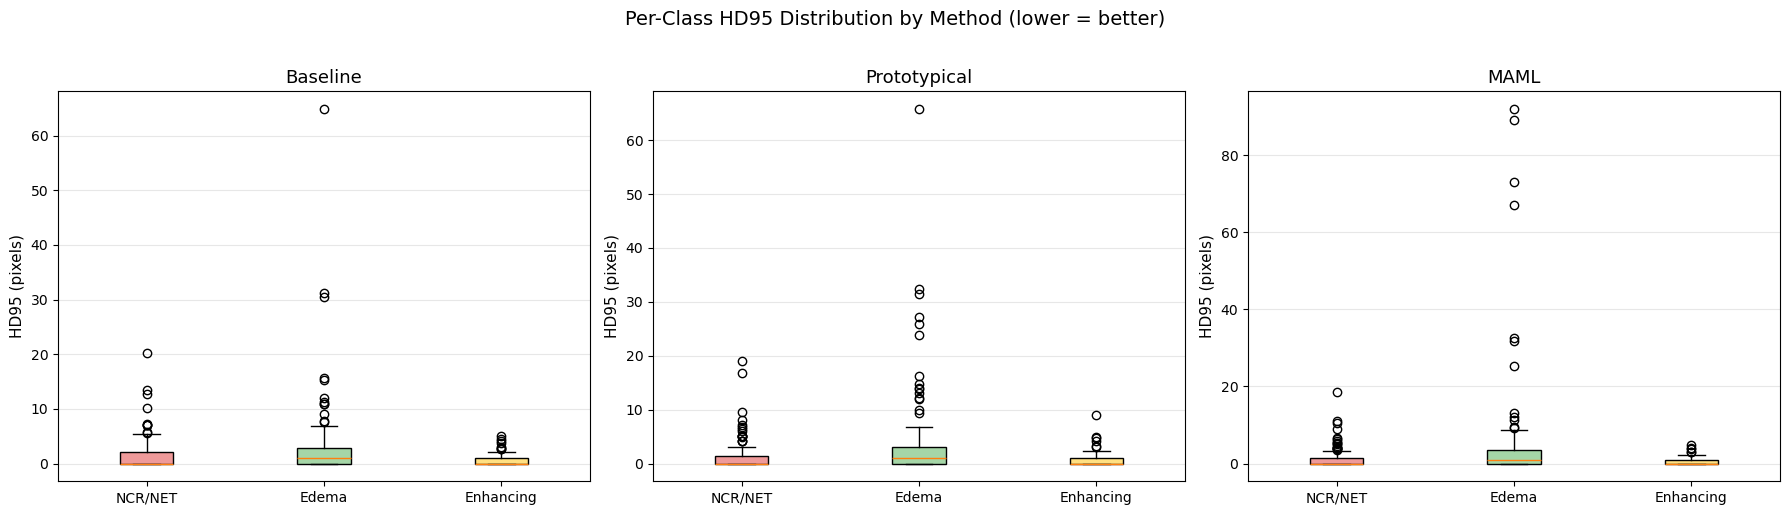

In [9]:
# CELL 10: Error Analysis HD95 — All Three Models
def error_analysis_hd95_all(models, model_names, dataset, num_samples=100,
                            save_name='error_analysis_hd95_all.png'):
    """Per-class HD95 distribution for multiple models side by side."""
    from configs.metrics import hd95_multiclass

    class_names = ['NCR/NET', 'Edema', 'Enhancing']
    n_models = len(models)

    indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))

    # Collect HD95 for each model
    all_results = {}
    for name, model in zip(model_names, models):
        all_hd95 = {c: [] for c in range(1, 4)}
        for idx in indices:
            sample = dataset[idx]
            image = sample['image'].unsqueeze(0).to(Config.DEVICE)
            mask = sample['mask'].unsqueeze(0).to(Config.DEVICE)
            with torch.no_grad():
                pred = torch.argmax(model(image), dim=1)
            scores = hd95_multiclass(pred, mask)
            for c in range(1, 4):
                val = scores[f'hd95_class_{c}']
                if np.isfinite(val):
                    all_hd95[c].append(val)
        all_results[name] = all_hd95

    # Plot side by side
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
    if n_models == 1:
        axes = [axes]

    colors_box = ['#EF9A9A', '#A5D6A7', '#FFE082']

    for ax, name in zip(axes, model_names):
        data = [all_results[name][c] for c in range(1, 4)]
        bp = ax.boxplot(data, labels=class_names, patch_artist=True)
        for patch, color in zip(bp['boxes'], colors_box):
            patch.set_facecolor(color)
        ax.set_ylabel('HD95 (pixels)', fontsize=11)
        ax.set_title(f'{name}', fontsize=13)
        ax.grid(True, alpha=0.3, axis='y')

    plt.suptitle('Per-Class HD95 Distribution by Method (lower = better)',
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(Config.RESULTS_DIR, save_name),
                dpi=150, bbox_inches='tight')
    plt.show()

error_analysis_hd95_all(
    models=[baseline_model, proto_model, maml_model],
    model_names=['Baseline', 'Prototypical', 'MAML'],
    dataset=val_dataset,
)

In [10]:
# CELL 11: Summary Table (Dice + HD95)

# Dice table
print_comparison_table([
    ('Baseline Fine-tuning', baseline_results),
    ('Prototypical Networks', proto_results),
    ('MAML', maml_results),
], Config.K_SHOT_VALUES)

# HD95 table
print(f"\n{'='*70}")
print("HD95 COMPARISON (lower = better)")
print(f"{'='*70}")
print(f"{'Method':<25} {'k=1':<12} {'k=5':<12} {'k=10':<12} {'k=20':<12}")
print(f"{'-'*70}")

for name, results in [('Baseline Fine-tuning', baseline_results),
                       ('Prototypical Networks', proto_results),
                       ('MAML', maml_results)]:
    if results is None:
        continue
    if 'hd95_mean' not in results[str(Config.K_SHOT_VALUES[0])]:
        print(f"  {name:<23} — no HD95 data")
        continue
    row = f"{name:<25}"
    for k in Config.K_SHOT_VALUES:
        r = results[str(k)]
        row += f" {r['hd95_mean']:.1f}±{r['hd95_std']:.1f}     "
    print(row)

print(f"{'='*70}")


METHOD COMPARISON
Method                    k=1          k=5          k=10         k=20        
----------------------------------------------------------------------
Baseline Fine-tuning      0.595±0.137   0.732±0.083   0.736±0.078   0.735±0.078  
Prototypical Networks     0.799±0.052   0.795±0.086   0.797±0.061   0.829±0.059  
MAML                      0.775±0.070   0.800±0.067   0.800±0.061   0.823±0.072  

HD95 COMPARISON (lower = better)
Method                    k=1          k=5          k=10         k=20        
----------------------------------------------------------------------
Baseline Fine-tuning      20.4±15.5      4.0±2.8      3.1±1.0      3.0±1.0     
Prototypical Networks     1.9±1.0      1.9±1.0      2.0±1.2      1.9±1.2     
MAML                      9.5±7.9      2.9±3.9      2.7±2.7      2.1±1.8     
